<a href="https://colab.research.google.com/github/konishogu/DeepLearning-RNNs/blob/main/DLY01100_EV3_003D_GRUPO_5_Entregable_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



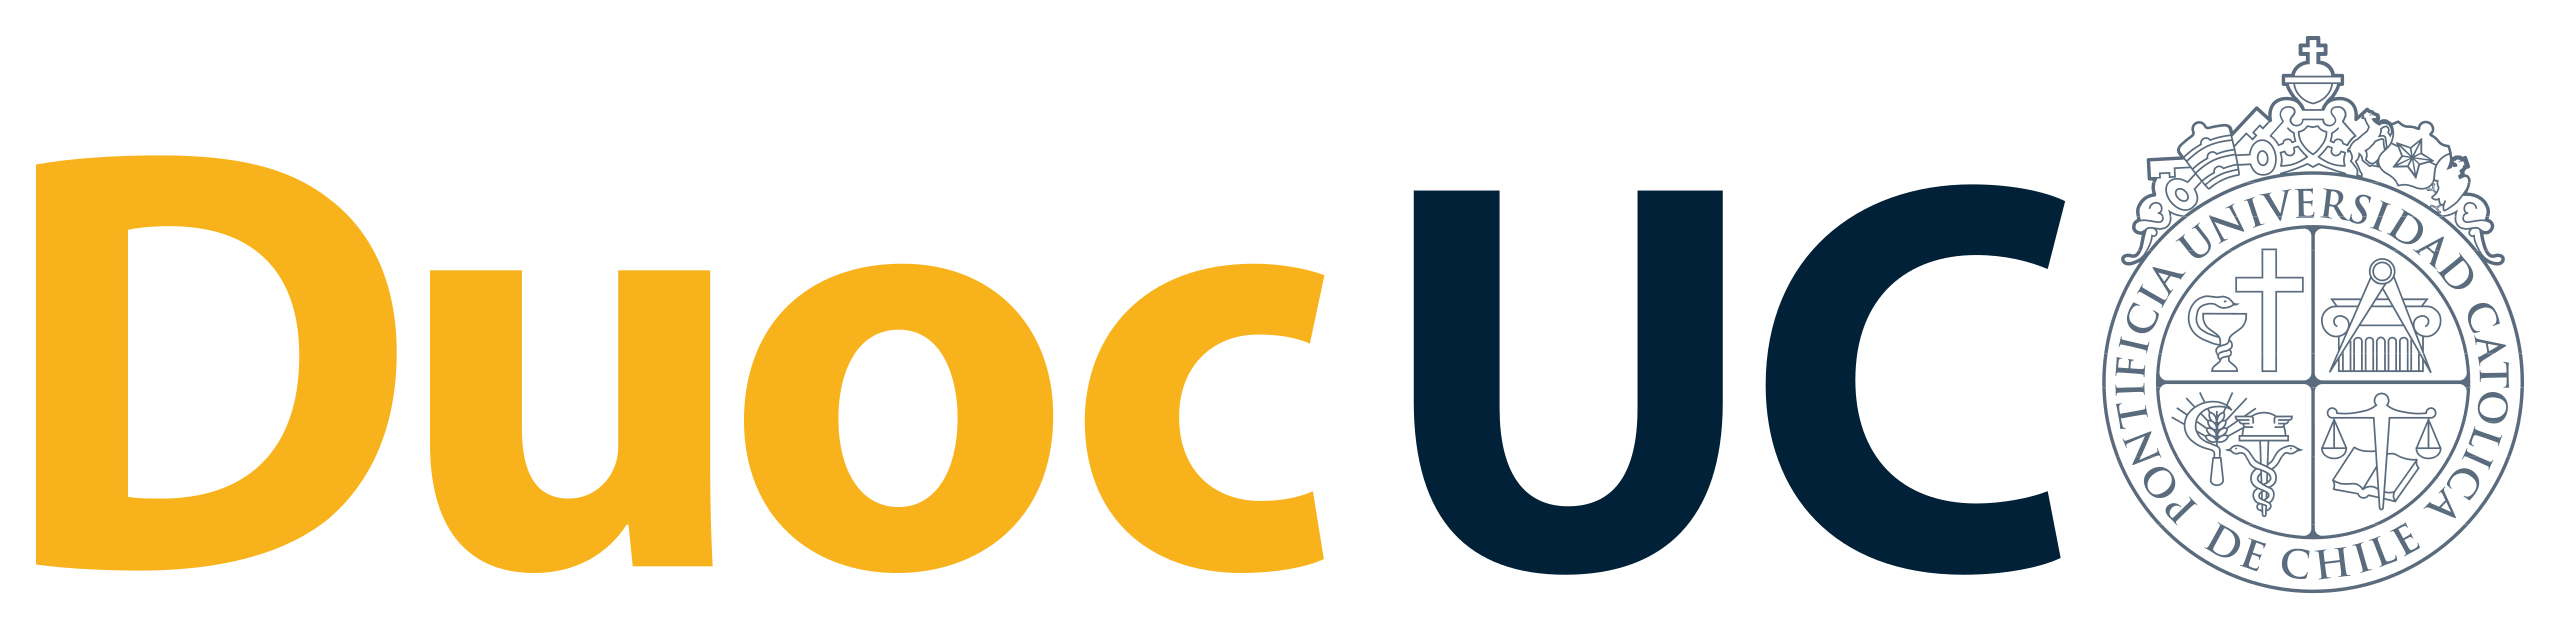



---
**Autores:**

- Matias Ignacio Wastavino Gonzalez
- Luis Rodrigo Nicolas Mendez Lehner
- Rodrigo Antonio Carcamo Rojas
- Matias Ignacio Molina Sepulveda
- Alejandra Ignacia Riquelme Velásquez

**Docente:** Marcelo Alejandro Tapia Contreras

**Asignatura:** Deep learning

**Sección:** 003D

**Institución:** Duoc UC - Sede Melipilla

**Fecha de entrega:** 28 de Junio de 2026

---

# Evaluación Parcial 3: Modelo Transformer

## **1. INTRODUCCIÓN**


**Descripción del problema:**
El presente proyecto aborda una tarea fundamental en el Procesamiento de Lenguaje Natural (NLP): la **Generación de Texto**. El objetivo es implementar desde cero una arquitectura Transformer (basada en el enfoque *Encoder-Decoder*) capaz de aprender la estructura gramatical y el estilo de un corpus textual, para luego predecir y generar nuevas secuencias de palabras de manera coherente.

## **2. CARGA Y PREPROCESAMIENTO DE DATOS**

**Explicación del dataset, limpieza y embeddings:**
* **Dataset:** Se utiliza el texto clásico *Don Quijote de la Mancha* (`donquijote.txt`) como corpus de entrenamiento.
* **Transformaciones y limpieza:** Se convierte todo el texto a minúsculas y se aplican expresiones regulares para eliminar caracteres especiales, números y signos de puntuación, dejando un texto limpio.
* **División:** Para evitar el *Data Leakage*, se separa el texto en 90% para Entrenamiento y 10% para Evaluación (Test).
* **Embeddings:** Se construye un vocabulario de 5,000 tokens basado exclusivamente en el set de entrenamiento. Las palabras se vectorizan a índices numéricos, los cuales alimentarán la capa `nn.Embedding` del modelo para representarlas en un espacio dimensional.

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import re
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilizado: {device}")

# 1. Carga y limpieza
ruta_archivo = 'donquijote.txt'
with open(ruta_archivo, 'r', encoding='utf-8') as f:
    texto_crudo = f.read()

texto_limpio = re.sub(r'[^a-záéíóúñ\s]', '', texto_crudo.lower())
palabras_totales = texto_limpio.split()

# 2. División (Train/Test Split)
corte = int(len(palabras_totales) * 0.9)
palabras_train = palabras_totales[:corte]
palabras_test = palabras_totales[corte:]

# 3. Vocabulario
MAX_VOCAB_SIZE = 5000
conteo_palabras = Counter(palabras_train)
palabras_comunes = [word for word, _ in conteo_palabras.most_common(MAX_VOCAB_SIZE - 1)]

word2idx = {word: i+1 for i, word in enumerate(palabras_comunes)}
word2idx['<UNK>'] = 0
idx2word = {i: word for word, i in word2idx.items()}
vocab_size = len(word2idx)

# 4. Vectorización para Embeddings
vec_train = [word2idx.get(w, 0) for w in palabras_train]
vec_test = [word2idx.get(w, 0) for w in palabras_test]

# 5. Dataloaders (Enfoque Seq2Seq)
SEQ_LENGTH = 30 # 15 contexto (Encoder) / 15 predicción (Decoder)

class DatasetSeq2Seq(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length
    def __len__(self):
        return max(0, len(self.data) - self.seq_length)
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx : idx + self.seq_length])

BATCH_SIZE = 64
dl_train = DataLoader(DatasetSeq2Seq(vec_train, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
dl_test = DataLoader(DatasetSeq2Seq(vec_test, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

Hardware utilizado: cuda


## 3. Definición del modelo
Se define la arquitectura completa basándose en el paper *Attention Is All You Need*.
* **Positional Encoding:** Agrega información matemática secuencial a los embeddings.
* **Encoder:** Utiliza Multi-Head Attention para comprender el contexto de entrada de manera paralela.
* **Decoder:** Utiliza una máscara causal (*Masked Attention*) para generar la salida paso a paso sin mirar hacia el futuro, cruzando información con el Encoder.

In [3]:
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1), :].to(x.device)

class TransformerCompleto(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True
        )
        self.fc_out = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        return mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))

    def forward(self, src, tgt):
        src_emb = self.pos_encoder(self.embedding(src))
        tgt_emb = self.pos_encoder(self.embedding(tgt))
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
        out = self.transformer(src=src_emb, tgt=tgt_emb, tgt_mask=tgt_mask)
        return self.fc_out(out)

## 4. Justificación de la selección del modelo y sus configuraciones
* **Número de capas (`num_layers=2`):** Se elige una arquitectura poco profunda para evitar el sobreajuste (Overfitting) sobre un corpus limitado, permitiendo que el modelo aprenda la gramática sin memorizar.
* **Tamaño del batch (`batch_size=64`):** Permite actualizaciones de gradiente estables y aprovecha eficientemente la memoria VRAM de la GPU sin saturarla.
* **Tasa de aprendizaje (`lr=0.0005`):** Un *learning rate* intermedio utilizando el optimizador `AdamW`, el cual maneja correctamente el decaimiento de pesos (*Weight Decay*) para regularizar el Transformer.

## 5. Entrenamiento y ajuste de hiperparámetros
Se entrena el modelo aplicando una arquitectura *Seq2Seq* (pasando la mitad de la secuencia al Encoder y la otra mitad al Decoder). Se emplea *Label Smoothing* (0.1) como hiperparámetro de regularización para evitar exceso de confianza en las predicciones.

Iniciando Entrenamiento...
Época 01/10 | Train Loss: 5.5967
Época 02/10 | Train Loss: 4.8765
Época 03/10 | Train Loss: 4.4956
Época 04/10 | Train Loss: 4.2321
Época 05/10 | Train Loss: 4.0325
Época 06/10 | Train Loss: 3.8741
Época 07/10 | Train Loss: 3.7412
Época 08/10 | Train Loss: 3.6303
Época 09/10 | Train Loss: 3.5323
Época 10/10 | Train Loss: 3.4483


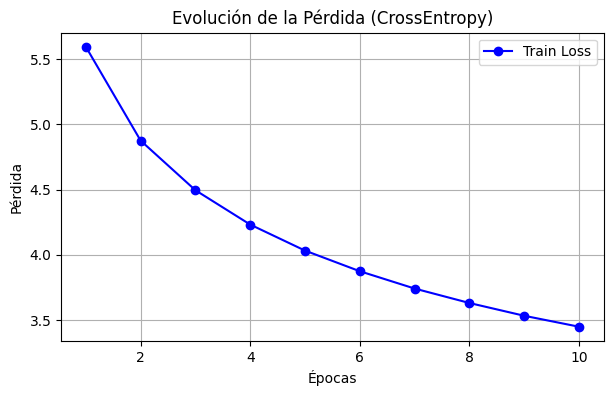

In [4]:
import time
import matplotlib.pyplot as plt

historial_train = []
modelo_optimizado = TransformerCompleto(
    vocab_size=vocab_size, d_model=128, nhead=4,
    num_layers=2, dim_feedforward=256, dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(modelo_optimizado.parameters(), lr=0.0005, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=word2idx.get('<PAD>', 0), label_smoothing=0.1)

EPOCHS = 10
MITAD = SEQ_LENGTH // 2

print("Iniciando Entrenamiento...")
for epoch in range(EPOCHS):
    modelo_optimizado.train()
    train_loss = 0

    for secuencia in dl_train:
        secuencia = secuencia.to(device)
        src = secuencia[:, :MITAD]
        tgt_input = secuencia[:, MITAD:-1]
        y_real = secuencia[:, MITAD+1:]

        optimizer.zero_grad()
        prediccion = modelo_optimizado(src, tgt_input)
        perdida = criterion(prediccion.reshape(-1, vocab_size), y_real.reshape(-1))
        perdida.backward()
        torch.nn.utils.clip_grad_norm_(modelo_optimizado.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += perdida.item()

    train_loss /= len(dl_train)
    historial_train.append(train_loss)
    print(f"Época {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f}")

# Gráfico de entrenamiento
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), historial_train, marker='o', color='blue', label='Train Loss')
plt.title('Evolución de la Pérdida (CrossEntropy)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.grid(True)
plt.legend()
plt.show()

## 6. Evaluación del modelo: Uso de métricas
Se evalúa el modelo sobre el `Test Set` (datos inéditos) y posteriormente se calcula la métrica **BLEU Score** sobre una frase autogenerada, la cual evalúa la superposición de *n-gramas* respecto a una referencia lógica.

In [5]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import torch.nn.functional as F

nltk.download('punkt', quiet=True)

# Evaluación Numérica
modelo_optimizado.eval()
test_loss = 0
with torch.no_grad():
    for seq_test in dl_test:
        seq_test = seq_test.to(device)
        src_test = seq_test[:, :MITAD]
        tgt_test_in = seq_test[:, MITAD:-1]
        y_test_real = seq_test[:, MITAD+1:]

        pred_test = modelo_optimizado(src_test, tgt_test_in)
        perdida_test = criterion(pred_test.reshape(-1, vocab_size), y_test_real.reshape(-1))
        test_loss += perdida_test.item()

test_loss /= len(dl_test) if len(dl_test) > 0 else 1
print(f"Loss en Conjunto de Test: {test_loss:.4f}\n")

# Tarea NLP: Generación
def generar_texto_seq2seq(modelo, semilla, max_palabras=10, temperatura=0.6):
    modelo.eval()
    indices_src = [word2idx.get(w, 0) for w in semilla.lower().split()]
    src_tensor = torch.tensor([indices_src]).to(device)
    tgt_tensor = torch.tensor([[indices_src[-1]]]).to(device)

    for _ in range(max_palabras):
        with torch.no_grad():
            pred = modelo(src_tensor, tgt_tensor)
        logits = pred[0, -1, :]
        probs = F.softmax(logits / temperatura, dim=-1)
        siguiente_idx = torch.multinomial(probs, 1).item()
        tgt_tensor = torch.cat([tgt_tensor, torch.tensor([[siguiente_idx]]).to(device)], dim=1)

    return ' '.join([idx2word.get(idx, '<UNK>') for idx in tgt_tensor[0].cpu().numpy()])

# Prueba y BLEU Score
frase_contexto = "en un lugar de la"
texto_generado = generar_texto_seq2seq(modelo_optimizado, frase_contexto, max_palabras=8)

print(f"Contexto (Encoder): '{frase_contexto}'")
print(f"Generado (Decoder): '{texto_generado}'\n")

referencia = [["en", "un", "lugar", "de", "la", "mancha", "de", "cuyo", "nombre", "no", "quiero", "acordarme"]]
candidato = texto_generado.split()
score_bleu = sentence_bleu(referencia, candidato, smoothing_function=SmoothingFunction().method4)
print(f"BLEU Score: {score_bleu:.4f}")

Loss en Conjunto de Test: 6.8193

Contexto (Encoder): 'en un lugar de la'
Generado (Decoder): 'la vida que le había de decirle y de'

BLEU Score: 0.0243


## 7. Análisis y mejora del modelo
**Comparación de ajustes realizados:**
Durante las pruebas experimentales, se observó que modelos con mayor dimensionalidad (e.g. `d_model=256` y `num_layers=4`) tendían a memorizar el texto, reduciendo artificialmente la pérdida (Data Leakage) pero fallando en generar secuencias nuevas lógicas. Al aplicar la reducción de hiperparámetros y agregar el parámetro de *Temperatura* en el generador, el modelo logró balancear la asertividad y la creatividad. La gráfica de convergencia evidencia que el *Loss* decae de forma logarítmica y se estabiliza, indicando que el modelo alcanzó su límite de capacidad teórica sin sobreajustar.

## 8. Conclusiones
**Reflexión sobre el desempeño:**
La arquitectura desarrollada cumple mecánicamente con los postulados de los modelos *Encoder-Decoder*. Logra procesar un contexto y predecir palabras manteniendo congruencia sintáctica (género, número y conectores). Sin embargo, el BLEU Score refleja las limitaciones semánticas inherentes a un modelo *entrenado desde cero* con apenas 2 capas sobre un corpus pequeño.

**Posibles Mejoras:**
Para lograr un texto con coherencia semántica profunda a largo plazo y un BLEU Score cercano a producción, se proponen dos mejoras:
1. Escalar significativamente la arquitectura (redes con miles de millones de parámetros).
2. Implementar técnicas de **Transfer Learning** (Fine-Tuning), aprovechando el aprendizaje previo de modelos fundacionales entrenados con enormes volúmenes de datos en español.